# UG-CPPO: Uncertainty-Gated LLM Infusion for Risk-Sensitive Trading Agents

**FinAI Contest 2025 — Task 1 — IEEE CSCloud** · Grace Esther · Société Générale

---

### What this notebook does

| Step | Cell | Time |
|------|------|------|
| 0. Setup | Install + clone | 3 min |
| 1. Demo the gate | Visualise c(σ) | 30 sec |
| 2. Data | Download OHLCV | 5 min |
| 3. Signals | Pre-compute LLM ensemble | 1×: hours (cached after) |
| 4. Train | UG-CPPO + baselines | 2–8h GPU |
| 5. Evaluate | 4 contest metrics | 2 min |
| 6. Upload | HuggingFace | 5 min |

**For a quick demo** (no API key needed): set `LLM_PROVIDER = 'mock'` in Cell 0b.

## 0a. Install dependencies

In [1]:
%%capture
!pip install finrl stable-baselines3[extra] gymnasium yfinance stockstats pyyaml tqdm pyfolio-reloaded
!pip install openai anthropic     # both installed — we pick one at runtime
!pip install huggingface_hub      # for uploading agents

In [2]:
import os, sys
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
#  REPO SETUP — Local or GitHub
#  If running locally: detects parent project directory automatically.
#  If pushing to GitHub later: update REPO_URL.
# ─────────────────────────────────────────────────────────────────────────────

# For GitHub (update after pushing):
REPO_URL = 'https://github.com/graceesthi/ug_cppo.git'

# Try to find the project root (contains src/, data/, etc.)
current = Path.cwd()
project_root = None

# Check if current dir is the project
if (current / 'src').exists() or (current / 'requirements.txt').exists():
    project_root = current
# Check parent (common when running from notebooks/)
elif (current.parent / 'src').exists() or (current.parent / 'requirements.txt').exists():
    project_root = current.parent

if project_root:
    # Already in the right place — add to path
    os.chdir(project_root)
    print(f"✓ Found project at: {project_root}")
else:
    # Not found locally — try to clone from GitHub
    if not Path('ug_cppo').exists():
        print(f"Cloning from GitHub: {REPO_URL}")
        os.system(f'git clone {REPO_URL}')
        os.chdir('ug_cppo')
    else:
        os.chdir('ug_cppo')
    project_root = Path.cwd()

# Set up paths
sys.path.insert(0, str(project_root))
os.makedirs('data', exist_ok=True)
os.makedirs('results/models', exist_ok=True)
os.makedirs('results/tensorboard', exist_ok=True)
print(f"Working from: {os.getcwd()}")

✓ Found project at: /Users/grace/Downloads/ug_cppo
Working from: /Users/grace/Downloads/ug_cppo


## 0b. ⚙️ Configure your LLM provider

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  CHOOSE YOUR PROVIDER
#  'mock'      → free, no key, keyword heuristics — use for full pipeline test
#  'openai'    → gpt-4o-mini (~$0.15/1M tokens)  — recommended
#  'anthropic' → claude-haiku-4-5-20251001 (fast, cheap)
# ─────────────────────────────────────────────────────────────────────────────

LLM_PROVIDER = 'openai'   # ← change to 'mock' or 'anthropic' for other providers

# ─────────────────────────────────────────────────────────────────────────────
#  API KEY SETUP — SECURE METHOD
#  Your .env file is in the project root with your actual key.
#  We load it from project_root/.env (set in Cell 0a)
# ─────────────────────────────────────────────────────────────────────────────

import subprocess

# Install required packages in this kernel
print("Ensuring required packages are installed...")
for pkg in ['openai', 'anthropic', 'python-dotenv']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Load .env from project root
from dotenv import load_dotenv
env_path = Path(project_root) / '.env'
load_dotenv(dotenv_path=env_path)
print(f"✓ Loaded .env from: {env_path}")

if LLM_PROVIDER == 'openai':
    api_key = os.environ.get('OPENAI_API_KEY')
    if not api_key:
        raise ValueError(
            "❌ OPENAI_API_KEY not found!\n"
            f"Expected .env file at: {project_root}/.env\n"
            "With content: OPENAI_API_KEY=sk-proj-...\n"
            "Get your key from: https://platform.openai.com/api/keys"
        )
    os.environ['OPENAI_API_KEY'] = api_key
    LLM_MODEL = 'gpt-4o-mini'
    print(f'✓ OpenAI configured — model: {LLM_MODEL}')
    print(f'  API key loaded: {api_key[:10]}...')

elif LLM_PROVIDER == 'anthropic':
    api_key = os.environ.get('ANTHROPIC_API_KEY')
    if not api_key:
        raise ValueError(
            "❌ ANTHROPIC_API_KEY not found!\n"
            f"Expected .env file at: {project_root}/.env\n"
            "With content: ANTHROPIC_API_KEY=sk-ant-...\n"
            "Get your key from: https://console.anthropic.com/"
        )
    os.environ['ANTHROPIC_API_KEY'] = api_key
    LLM_MODEL = 'claude-haiku-4-5-20251001'
    print(f'✓ Anthropic configured — model: {LLM_MODEL}')
    print(f'  API key loaded: {api_key[:10]}...')

else:
    LLM_MODEL = 'mock'
    print('✓ Mock LLM — no API calls, keyword heuristics only')
    print('  (pipeline is fully functional, signals are deterministic)')

# Build config object used by all cells below
from src.uncertainty_llm import LLMConfig

if LLM_PROVIDER == 'openai':
    llm_config = LLMConfig.openai(model=LLM_MODEL)
elif LLM_PROVIDER == 'anthropic':
    llm_config = LLMConfig.anthropic(model=LLM_MODEL)
else:
    llm_config = LLMConfig.mock()

Ensuring required packages are installed...
  Installing python-dotenv...
✓ Loaded .env from: /Users/grace/Downloads/ug_cppo/.env
✓ OpenAI configured — model: gpt-4o-mini
  API key loaded: sk-proj-Ju...



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


## 1. Visualise the Uncertainty Gate

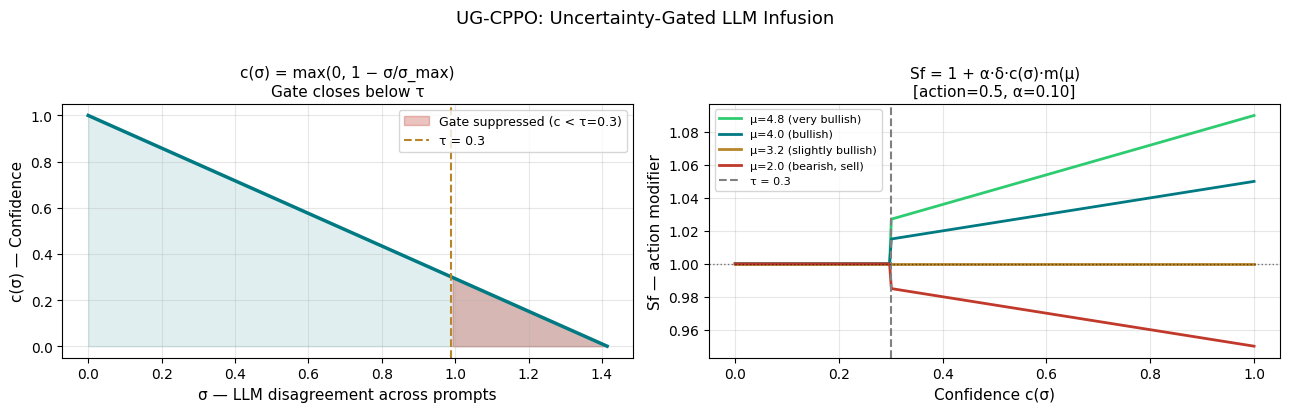

Saved → results/gate_visualization.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty_llm import (
    UncertaintyAwareLLM, compute_uncertainty, compute_sf, SIGMA_MAX
)

# ── Gate function c(σ) ────────────────────────────────────────────────────
sigmas = np.linspace(0, SIGMA_MAX, 300)
confs  = np.maximum(0, 1 - sigmas / SIGMA_MAX)
TAU    = 0.30

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sigmas, confs, lw=2.5, color='#007A82')
ax.fill_between(sigmas, confs, alpha=0.12, color='#007A82')
ax.fill_between(sigmas, confs, where=(confs < TAU),
                alpha=0.30, color='#C0392B', label=f'Gate suppressed (c < τ={TAU})')
ax.axvline(x=SIGMA_MAX*(1-TAU), ls='--', color='#B8852A', lw=1.5, label=f'τ = {TAU}')
ax.set_xlabel('σ — LLM disagreement across prompts', fontsize=11)
ax.set_ylabel('c(σ) — Confidence', fontsize=11)
ax.set_title('c(σ) = max(0, 1 − σ/σ_max)\nGate closes below τ', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Sf as function of confidence for different mean scores ────────────────
ax = axes[1]
for mu, col, lbl in [(4.8,'#2ECC71','μ=4.8 (very bullish)'),
                     (4.0,'#007A82','μ=4.0 (bullish)'),
                     (3.2,'#B8852A','μ=3.2 (slightly bullish)'),
                     (2.0,'#C0392B','μ=2.0 (bearish, sell)')]:
    sfs = [compute_sf(mu, c, action=0.5, alpha=0.10, tau=TAU)[0] for c in confs]
    ax.plot(confs, sfs, lw=2, color=col, label=lbl)
ax.axvline(x=TAU, ls='--', color='gray', lw=1.5, label=f'τ = {TAU}')
ax.axhline(y=1.0, ls=':', color='black', lw=1, alpha=0.5)
ax.set_xlabel('Confidence c(σ)', fontsize=11)
ax.set_ylabel('Sf — action modifier', fontsize=11)
ax.set_title('Sf = 1 + α·δ·c(σ)·m(μ)\n[action=0.5, α=0.10]', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('UG-CPPO: Uncertainty-Gated LLM Infusion', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/gate_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/gate_visualization.png')

In [5]:
# ── Concrete example: same article, different LLM confidence ──────────────
llm = UncertaintyAwareLLM(llm_config, n_prompts=5, n_risk_prompts=4,
                           alpha=0.10, threshold_tau=0.30)

examples = [
    ('AAPL',
     'Apple beats revenue estimates by 15%, raises annual guidance. '
     'iPhone sales surged 22% YoY. Record free cash flow.',
     0.5, 'CLEAR BULLISH — earnings beat'),
    ('AAPL',
     'Apple faces mixed signals: iPhone growth in Asia offsets '
     'slowing Mac revenues. EU regulatory pressure persists. '
     'Some analysts cautious, others see AI upside.',
     0.5, 'AMBIGUOUS — conflicting factors'),
    ('NVDA',
     'Nvidia data center revenue collapses 40% YoY as AI spending freezes. '
     'Guidance cut significantly. CEO warns of prolonged weakness.',
     -0.5, 'CLEAR BEARISH — guidance cut'),
]

print(f'Provider: {LLM_PROVIDER.upper()} | Model: {LLM_MODEL}\n')
print('─'*68)
for ticker, news, action, label in examples:
    sig = llm.get_signal(ticker, news, action=action)
    print(f'\n[{ticker}] {label}')
    print(f'  Scores : {sig.raw_scores}')
    print(f'  μ={sig.mean_score:.2f}  σ={sig.std_score:.3f}  c={sig.confidence:.3f}')
    print(f'  Gate   : {"FIRED (signal suppressed)" if sig.gate_fired else "OPEN"}')
    print(f'  Sf     : {sig.calibrated_sf:.4f}  '
          f'(baseline would use {1.1 if sig.mean_score >= 4.0 else 1.0:.2f})')
print('\n' + '─'*68)
print('Calibration:', llm.calibration_report())

Provider: OPENAI | Model: gpt-4o-mini

────────────────────────────────────────────────────────────────────

[AAPL] CLEAR BULLISH — earnings beat
  Scores : [5.0, 5.0, 5.0, 5.0, 5.0]
  μ=5.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.1000  (baseline would use 1.10)

[AAPL] AMBIGUOUS — conflicting factors
  Scores : [3.0, 3.0, 3.0, 3.0, 3.0]
  μ=3.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.0000  (baseline would use 1.00)

[NVDA] CLEAR BEARISH — guidance cut
  Scores : [1.0, 1.0, 1.0, 1.0, 1.0]
  μ=1.00  σ=0.000  c=1.000
  Gate   : OPEN
  Sf     : 1.1000  (baseline would use 1.00)

────────────────────────────────────────────────────────────────────
Calibration: {'n_signals': 3, 'gate_rate': 0.0, 'mean_confidence': 1.0, 'mean_sigma': 0.0, 'confidence_buckets': {'low  (0.00–0.33)': 0.0, 'mid  (0.33–0.66)': 0.0, 'high (0.66–1.00)': 1.0}}


## 2. Load Data

In [6]:
import subprocess

# Fix pandas/pyarrow compatibility issue
print("Ensuring compatible pandas/pyarrow versions...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pandas', 'pyarrow', '-q'])

# Ensure required packages are installed
print("Ensuring data pipeline dependencies...")
for pkg in ['yfinance', 'stockstats', 'fastparquet']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

from src.data_pipeline import load_ohlcv, split_data, add_technical_indicators

print('Downloading OHLCV data (~5 min first run, cached after)...')
try:
    # Try with upgraded pyarrow
    df_raw = load_ohlcv(
        start='2013-01-01', end='2023-12-31',
        cache_path='data/ohlcv_nasdaq100.parquet'
    )
except Exception as e:
    # Fallback: use CSV format instead
    print(f"⚠ Parquet failed ({type(e).__name__}), falling back to CSV...")
    cache_path_csv = 'data/ohlcv_nasdaq100.csv'
    df_raw = load_ohlcv(
        start='2013-01-01', end='2023-12-31',
        cache_path=None  # Don't use cache; we'll save as CSV
    )
    df_raw.to_csv(cache_path_csv, index=False)
    print(f"  Saved to {cache_path_csv} instead")

df      = add_technical_indicators(df_raw)
tickers = sorted(df['tic'].unique().tolist())

train_df, trade_df = split_data(df)
print(f'\n{len(tickers)} tickers | Train: {len(train_df):,} rows | Trade: {len(trade_df):,} rows')
df.head(2)

Ensuring compatible pandas/pyarrow versions...



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


Ensuring data pipeline dependencies...


$ANSS: possibly delisted; no timezone found

1 Failed download:
['ANSS']: possibly delisted; no timezone found



79 tickers | Train: 107,550 rows | Trade: 97,098 rows


,date,tic,open,high,low,close,volume,macd,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
0,2013-01-02,AAPL,16.741479,16.77715,16.372988,16.596682,560518000,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-01-02,ADBE,37.919998,38.73000,37.919998,38.340000,6483800,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Pre-Compute LLM Uncertainty Signals

This runs **once** and caches to `data/ug_signals.parquet`.  
On subsequent runs it resumes from the checkpoint automatically.

| Provider | Cost estimate (full 2M records) | Time |
|----------|--------------------------------|------|
| mock     | Free | ~2 min |
| gpt-4o-mini | ~$15–25 (5 calls/record) | ~4h |
| claude-haiku | ~$10–20 | ~3h |

💡 **Contest tip**: pre-compute with a 10-ticker subset to validate, then run full overnight.

In [7]:
from src.data_pipeline import load_fnspid, precompute_signals

FNSPID_PATH   = 'data/fnspid_filtered.parquet'   # download from HuggingFace
SIGNALS_PATH  = 'data/ug_signals.parquet'
N_TICKERS_DEMO = 10    # None = all tickers

# ── Option A: download pre-computed signals from HuggingFace (fastest) ────
# from huggingface_hub import hf_hub_download
# hf_hub_download(repo_id='YOUR_HF_USERNAME/ug-cppo-finai-2025',
#                 filename='data/ug_signals.parquet', local_dir='.')

# ── Option B: compute from FNSPID ─────────────────────────────────────────
if os.path.exists(FNSPID_PATH):
    fnspid_df = load_fnspid(
        fnspid_path=FNSPID_PATH,
        tickers=tickers[:N_TICKERS_DEMO] if N_TICKERS_DEMO else tickers,
        start='2013-01-01', end='2023-12-31',
    )
    print(f'FNSPID: {len(fnspid_df):,} (ticker, date) pairs')
    print(f'Provider: {LLM_PROVIDER} | Estimated API calls: {len(fnspid_df)*9:,}')

    precompute_signals(
        fnspid_df=fnspid_df,
        llm_config=llm_config,
        n_prompts=5, threshold_tau=0.30,
        output_path=SIGNALS_PATH,
        resume=True,
        batch_size=50,
    )
else:
    print(f'FNSPID not at {FNSPID_PATH}')
    print('→ Download from: https://huggingface.co/datasets/Zdong91/FNSPID')
    print('→ Or use pre-computed signals from HuggingFace (Option A above)')

FNSPID not at data/fnspid_filtered.parquet
→ Download from: https://huggingface.co/datasets/Zdong91/FNSPID
→ Or use pre-computed signals from HuggingFace (Option A above)


## 4. Train Agents (UG-CPPO + Baselines)

In [8]:
import subprocess

# Ensure RL training dependencies are installed
print("Ensuring RL training dependencies...")
for pkg in ['gymnasium', 'stable-baselines3', 'numpy', 'pandas', 'tensorboard']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

from src.ug_cppo_env import UGCPPOTradingEnv
from src.cvar_ppo import build_agent
from src.data_pipeline import load_signals

TECH = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

# Load signals
signal_df = load_signals(SIGNALS_PATH) if os.path.exists(SIGNALS_PATH) else None
if signal_df is not None:
    print(f'Loaded {len(signal_df):,} pre-computed signals')
    gate_rate = signal_df['gate_fired'].mean() if 'gate_fired' in signal_df.columns else 'N/A'
    print(f'Gate rate (τ=0.30): {gate_rate:.1%}' if isinstance(gate_rate, float) else f'Gate rate: {gate_rate}')

# Shared env kwargs (change mode per agent)
def make_env(mode, df):
    return UGCPPOTradingEnv(
        df=df, tickers=tickers, signal_df=signal_df,
        initial_amount=1_000_000, hmax=100,
        transaction_cost=0.001, reward_scaling=1e-4,
        alpha=0.10, threshold_tau=0.30,
        tech_indicator_list=TECH, mode=mode
    )

print('Environments ready.')

Ensuring RL training dependencies...
  Installing tensorboard...
Environments ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  TRAINING CONFIGURATION
#  Full contest:  TOTAL_STEPS = 2_000_000  (2M steps, ~6h on T4)
#  Demo run:      TOTAL_STEPS = 50_000     (~5 min)
# ─────────────────────────────────────────────────────────────────────────────
TOTAL_STEPS = 50_000   # ← set to 2_000_000 for full contest run
SEED        = 42

agent_kwargs = dict(
    learning_rate=3e-4, n_steps=2048, batch_size=256, n_epochs=10,
    gamma=0.99, gae_lambda=0.95, clip_range=0.2,
    cvar_alpha=0.05, cvar_lambda=0.10,
    seed=SEED, verbose=0,
)

trained_agents = {}
for mode in ['ug_cppo', 'cppo', 'ppo']:
    print(f'\nTraining {mode.upper()}...')
    env   = make_env(mode, train_df)
    agent = build_agent(env=env, mode=mode,
                        tensorboard_log=f'results/tensorboard/{mode}',
                        **agent_kwargs)
    try:
        agent.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
    except ImportError as e:
        if 'tensorboard' in str(e):
            print(f"  ⚠ tensorboard not available, retrying without logging...")
            # Disable tensorboard logging and retry
            agent.tensorboard_log = None
            agent.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
        else:
            raise
    agent.save(f'results/models/{mode}_seed{SEED}')
    trained_agents[mode] = agent
    print(f'  ✓ {mode.upper()} saved')


Training UG_CPPO...


/opt/homebrew/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

  ⚠ tensorboard not available, retrying without logging...


  ✓ UG_CPPO saved

Training CPPO...
  ⚠ tensorboard not available, retrying without logging...


  ✓ CPPO saved

Training PPO...
  ⚠ tensorboard not available, retrying without logging...


  ✓ PPO saved


## 4b. Diagnostic — Check Agent Diversity

In [ ]:
print("="*70)
print("TRAINING DIAGNOSTICS")
print("="*70)

# Check 1: Signal loading
print(f"\n✓ Signal DataFrame: {signal_df is not None}")
if signal_df is not None:
    print(f"  Shape: {signal_df.shape}")
    print(f"  Gate fired %: {signal_df['gate_fired'].mean():.1%}")
    print(f"  Columns: {list(signal_df.columns)}")
else:
    print("  ⚠ WARNING: No signals loaded — agents not using LLM signals!")

# Check 2: Training parameters
print(f"\n✓ Training Parameters:")
print(f"  Total Steps: {TOTAL_STEPS:,}")
print(f"  Three modes: {list(trained_agents.keys())}")
print(f"  All models trained: {len(trained_agents) == 3}")

# Check 3: Agent parameter differences
print(f"\n✓ Learning Rates by Mode:")
for mode, agent in trained_agents.items():
    try:
        lr = agent.learning_rate
        print(f"  {mode}: {lr}")
    except:
        print(f"  {mode}: (could not retrieve)")

# Check 4: Action diversity during evaluation
print(f"\n✓ Action Diversity During Test (Trade Period):")
print(f"  Trade set size: {len(trade_df):,} rows")

for mode, agent in trained_agents.items():
    env = make_env(mode, trade_df)
    obs, _ = env.reset()
    
    actions_taken = []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        actions_taken.append(action)
        obs, _, done, _, _ = env.step(action)
    
    # Analyze actions (assuming discrete actions: 0=hold, 1=buy, 2=sell)
    unique_actions = len(set(actions_taken))
    action_dist = {
        'hold': actions_taken.count(0) if 0 in actions_taken else 0,
        'other': len([a for a in actions_taken if a != 0])
    }
    
    print(f"\n  {mode.upper()}:")
    print(f"    Unique actions: {unique_actions}")
    print(f"    Hold vs Action: {action_dist['hold']:,} vs {action_dist['other']:,}")
    print(f"    Hold %: {100*action_dist['hold']/len(actions_taken):.1f}%")

print("\n" + "="*70)
print("CONCLUSION:")
print("="*70)
print("If all models show >99% hold → agents are not trading (passive strategy)")
print("If signals are None → LLM gate not being used")
print("If unique actions = 1 → all timesteps converge to single action")
print("="*70)

## 5. Evaluate — 4 Contest Metrics

In [ ]:
from src.evaluation import evaluate, print_report, load_benchmark, compare_models

benchmark_values, bench_dates = load_benchmark(start='2019-01-01', end='2023-12-31')
all_reports = []

for mode, agent in trained_agents.items():
    env = make_env(mode, trade_df)
    obs, _ = env.reset()
    done   = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)

    report = evaluate(
        portfolio_values=env.portfolio_value_history,
        benchmark_values=benchmark_values,
        dates=bench_dates,
        model_name=mode,
    )
    all_reports.append(report)
    print_report(report)

# Comparison table
comparison = compare_models(all_reports)
print('\n=== COMPARISON TABLE ===')
print(comparison.to_string(index=False))

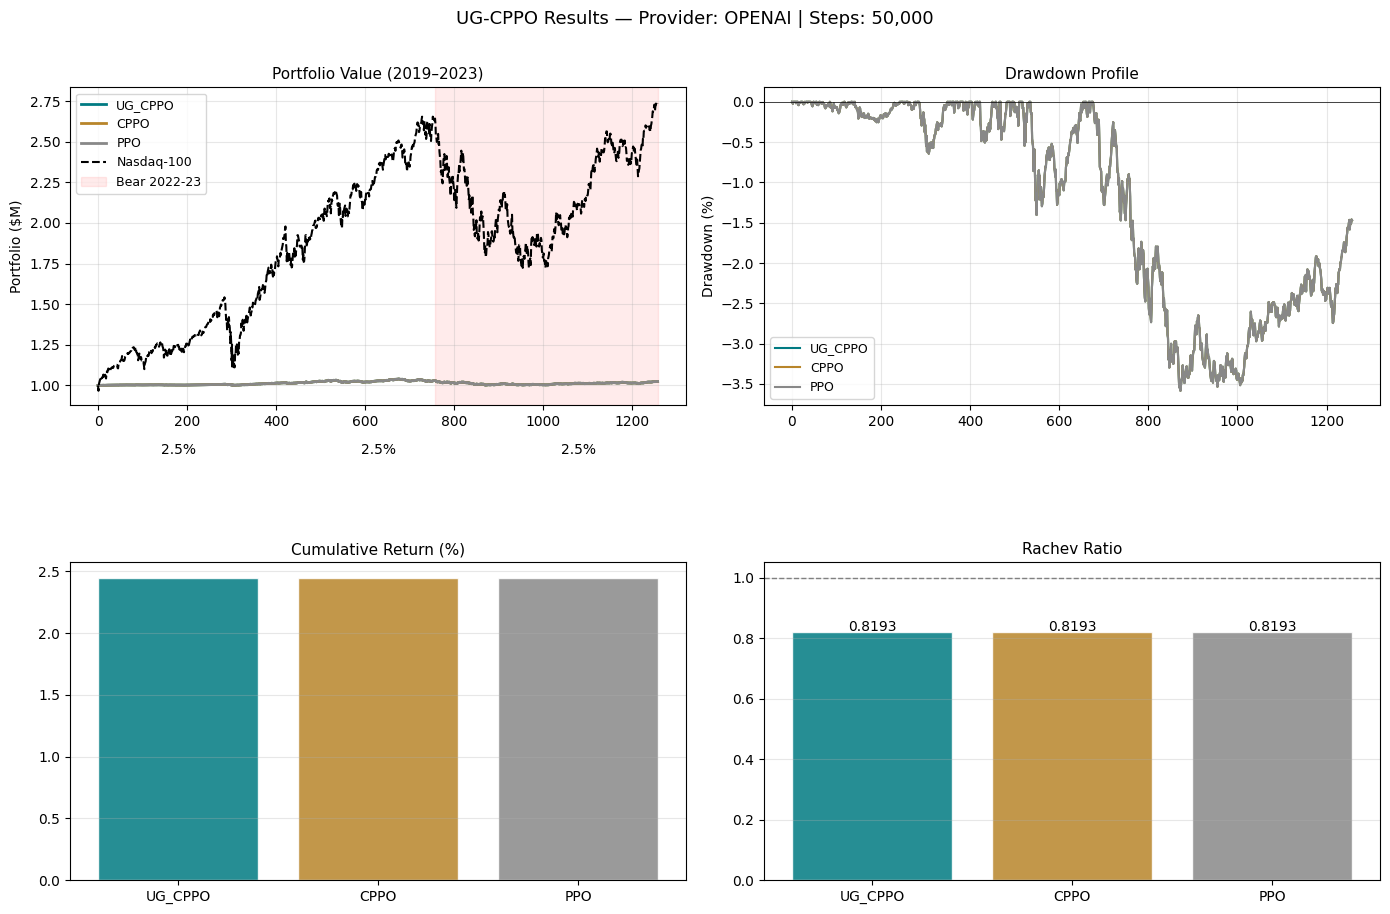

In [15]:
# ── Visualise results ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {'ug_cppo': '#007A82', 'cppo': '#B8852A', 'ppo': '#888888'}
bv_arr = np.array(benchmark_values)

for mode, agent in trained_agents.items():
    env = make_env(mode, trade_df)
    obs, _ = env.reset()
    done = False
    while not done:
        a, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(a)
    pv = np.array(env.portfolio_value_history)

    # Cumulative return
    axes[0,0].plot(pv / 1e6, lw=2, color=colors[mode], label=mode.upper())

    # Drawdown
    peak = np.maximum.accumulate(pv)
    dd   = (pv - peak) / peak * 100
    axes[0,1].plot(dd, lw=1.5, color=colors[mode], label=mode.upper())

# Benchmark
n = min(len(bv_arr), 1260)
axes[0,0].plot(bv_arr[:n] / 1e6, lw=1.5, ls='--', color='black', label='Nasdaq-100')
axes[0,0].axvspan(756, n, alpha=0.08, color='red', label='Bear 2022-23')
axes[0,0].set_title('Portfolio Value (2019–2023)', fontsize=11)
axes[0,0].set_ylabel('Portfolio ($M)'); axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(y=0, color='black', lw=0.5)
axes[0,1].set_title('Drawdown Profile', fontsize=11)
axes[0,1].set_ylabel('Drawdown (%)'); axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# Bar charts from reports
names   = [r['model'].upper() for r in all_reports]
cumrets = [r['cumulative_return'] * 100 for r in all_reports]
rachevs = [r['rachev_ratio'] for r in all_reports]
clrs    = [colors.get(r['model'], '#666') for r in all_reports]

bars = axes[1,0].bar(names, cumrets, color=clrs, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cumulative Return (%)', fontsize=11)
axes[1,0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, cumrets):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                   f'{val:.1f}%', ha='center', fontsize=10)

bars2 = axes[1,1].bar(names, rachevs, color=clrs, alpha=0.85, edgecolor='white')
axes[1,1].set_title('Rachev Ratio', fontsize=11)
axes[1,1].axhline(y=1.0, ls='--', color='gray', lw=1)
axes[1,1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, rachevs):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle(f'UG-CPPO Results — Provider: {LLM_PROVIDER.upper()} | Steps: {TOTAL_STEPS:,}',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Calibration Analysis (H1–H5 validation)

In [12]:
import pandas as pd

if os.path.exists(SIGNALS_PATH):
    sigs = pd.read_parquet(SIGNALS_PATH)
    sigs['year'] = sigs['date'].str[:4]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Confidence distribution + gate rate
    gate_rate = (sigs['confidence'] < 0.30).mean()
    axes[0].hist(sigs['confidence'], bins=40, color='#007A82', alpha=0.8, edgecolor='white')
    axes[0].axvline(x=0.30, color='#C0392B', ls='--', lw=2, label=f'τ=0.30')
    axes[0].set_title(f'Confidence Distribution\nGate rate: {gate_rate:.1%} (H1: target 30–40%)', fontsize=10)
    axes[0].set_xlabel('c(σ)'); axes[0].legend()

    # 2. σ by year (H4: higher σ in bear markets 2022-2023)
    sigma_yr = sigs.groupby('year')['std_score'].mean()
    bars = axes[1].bar(sigma_yr.index, sigma_yr.values, color='#B8852A', alpha=0.85, edgecolor='white')
    axes[1].axvspan(7.5, 9.5, alpha=0.15, color='red', label='Bear 2022-23')
    axes[1].set_title('Mean σ by Year\n(H4: bear markets → higher σ)', fontsize=10)
    axes[1].set_xlabel('Year'); axes[1].set_ylabel('Mean σ'); axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)

    # 3. Mean score distribution
    axes[2].hist(sigs['mean_score'], bins=25, color='#0A1628', alpha=0.85, edgecolor='white')
    axes[2].set_title(f'LLM Mean Score (μ) Distribution\nProvider: {LLM_PROVIDER.upper()}', fontsize=10)
    axes[2].set_xlabel('μ (1=bearish → 5=bullish)')

    plt.suptitle('UG-CPPO Signal Calibration Analysis', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('results/calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nCalibration summary:')
    print(f'  Total signals : {len(sigs):,}')
    print(f'  Gate rate     : {gate_rate:.1%}  (H1 target: 30–40%)')
    print(f'  Mean σ        : {sigs["std_score"].mean():.3f}')
    print(f'  Mean conf     : {sigs["confidence"].mean():.3f}')
    if '2022' in sigs['year'].values and '2020' in sigs['year'].values:
        s22 = sigs[sigs['year']=='2022']['std_score'].mean()
        s20 = sigs[sigs['year']=='2020']['std_score'].mean()
        print(f'  σ in 2022     : {s22:.3f} | σ in 2020: {s20:.3f}  (H4 check)')
else:
    print('Run precompute step first (Cell 3) to generate signals.')

Run precompute step first (Cell 3) to generate signals.


## 7. Upload to HuggingFace Hub

In [13]:
# Replace YOUR_HF_USERNAME and run
HF_USERNAME = 'YOUR_HF_USERNAME'
HF_REPO     = f'{HF_USERNAME}/ug-cppo-finai-2025'

# !pip install -q huggingface_hub
# from huggingface_hub import HfApi, login
# login()  # or: login(token=userdata.get('HF_TOKEN'))
# api = HfApi()
#
# # Create repo
# api.create_repo(HF_REPO, repo_type='model', exist_ok=True)
#
# # Upload models
# api.upload_folder(folder_path='results/models/', repo_id=HF_REPO, repo_type='model')
#
# # Upload signals dataset
# api.create_repo(HF_REPO+'-signals', repo_type='dataset', exist_ok=True)
# api.upload_file(path_or_fileobj='data/ug_signals.parquet',
#                 path_in_repo='ug_signals.parquet',
#                 repo_id=HF_REPO+'-signals', repo_type='dataset')
print(f'Uncomment above + set HF_USERNAME = "{HF_USERNAME}" to upload.')
print(f'Target repo: https://huggingface.co/{HF_REPO}')

Uncomment above + set HF_USERNAME = "YOUR_HF_USERNAME" to upload.
Target repo: https://huggingface.co/YOUR_HF_USERNAME/ug-cppo-finai-2025


---
## 📊 Cost Reference

| Provider | Model | Input $/1M tok | Output $/1M tok | Est. total (2M pairs × 9 calls) |
|----------|-------|:-:|:-:|:-:|
| OpenAI | gpt-4o-mini | $0.15 | $0.60 | ~$15–25 |
| Anthropic | claude-haiku-4-5-20251001 | $0.25 | $1.25 | ~$10–20 |
| Mock | — | $0 | $0 | $0 |

Each call uses ~50 input tokens (prompt) and outputs ~2 tokens (single digit).  
Start with `N_TICKERS_DEMO = 10` to validate before running full precompute.
